#Titanic Dataset Analysis


## Import Libraries and Load Dataset

In [4]:
import pandas as pd

df = pd.read_csv("titanic dataset.csv")

df.head()


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [5]:
print(df.columns)

print(df.shape)

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')
(1309, 28)


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [7]:
print(df.isnull().sum())

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64


## Data Cleaning

In [8]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)



In [9]:
# Remove useless columns
drop_cols = [col for col in df.columns if "zero" in col.lower()]
df.drop(columns=drop_cols, inplace=True)

In [10]:

df.rename(columns={
    "2urvived": "Survived",
    "Passengerid": "PassengerId",
    "sibsp": "SibSp"
}, inplace=True)


In [11]:

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

## Summary Statistics

In [12]:
print(df.columns)

print(df.shape)

print(df.head())


Index(['PassengerId', 'Age', 'Fare', 'Sex', 'SibSp', 'Parch', 'Pclass',
       'Embarked', 'Survived'],
      dtype='object')
(1309, 9)
   PassengerId   Age     Fare  Sex  SibSp  Parch  Pclass  Embarked  Survived
0            1  22.0   7.2500    0      1      0       3       2.0         0
1            2  38.0  71.2833    1      1      0       1       0.0         1
2            3  26.0   7.9250    1      0      0       3       2.0         1
3            4  35.0  53.1000    1      1      0       1       2.0         1
4            5  35.0   8.0500    0      0      0       3       2.0         0


In [13]:
print(df.describe())

       PassengerId          Age         Fare          Sex        SibSp  \
count  1309.000000  1309.000000  1309.000000  1309.000000  1309.000000   
mean    655.000000    29.503186    33.281086     0.355997     0.498854   
std     378.020061    12.905241    51.741500     0.478997     1.041658   
min       1.000000     0.170000     0.000000     0.000000     0.000000   
25%     328.000000    22.000000     7.895800     0.000000     0.000000   
50%     655.000000    28.000000    14.454200     0.000000     0.000000   
75%     982.000000    35.000000    31.275000     1.000000     1.000000   
max    1309.000000    80.000000   512.329200     1.000000     8.000000   

             Parch       Pclass     Embarked     Survived  
count  1309.000000  1309.000000  1309.000000  1309.000000  
mean      0.385027     2.294882     1.493506     0.261268  
std       0.865560     0.837836     0.814244     0.439494  
min       0.000000     1.000000     0.000000     0.000000  
25%       0.000000     2.000000  

In [14]:
df.describe(include="all")

,PassengerId,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.385027,2.294882,1.493506,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.865560,0.837836,0.814244,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,9.000000,3.000000,2.000000,1.000000


## Visualizations

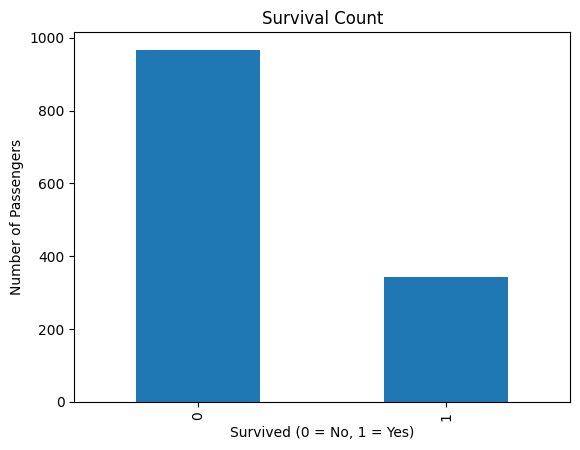

In [15]:
import matplotlib.pyplot as plt

df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()


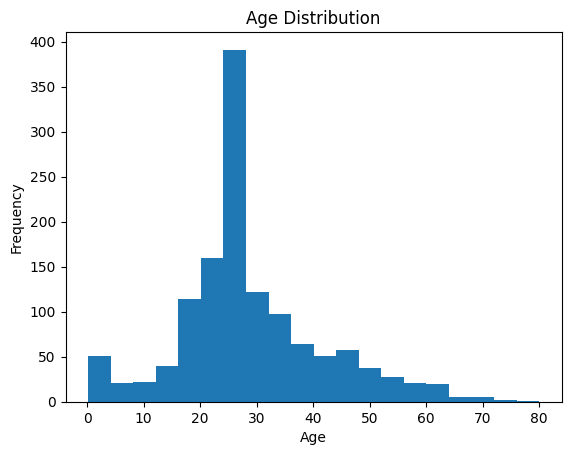

In [16]:
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

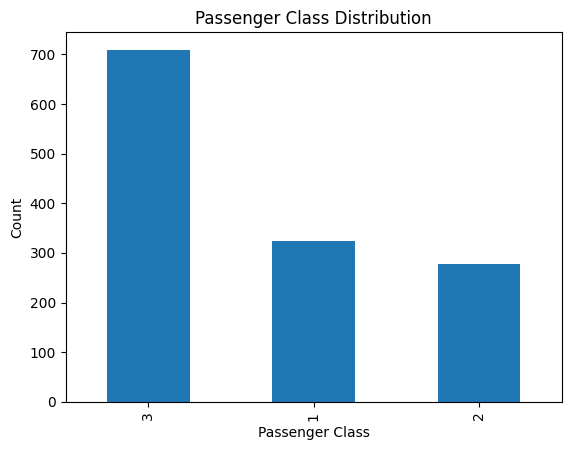

In [17]:
df["Pclass"].value_counts().plot(kind="bar")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

## Insights

1. Passenger Class 3 had the highest number of passengers compared to Class 1 and Class 2.

2. Most passengers were between 20 and 35 years old, indicating that adults formed the majority of travelers.

3. The number of passengers who did not survive was significantly higher than the number who survived.

4. The dataset required cleaning because it contained unnecessary columns and a few missing values that had to be handled.

5. Passenger fares showed a wide range of values, suggesting large differences in ticket prices among passengers.

# Task 2: Machine Learning Model Comparison

## Import Machine Learning Libraries


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Prepare Features and Target


In [19]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

print(X.shape)
print(y.shape)

(1309, 8)
(1309,)


## Split Training and Testing Data

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1047, 8)
(262, 8)


## K-Nearest Neighbors (KNN)

In [21]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7595419847328244


## Model Evaluation

### KNN Result

The K-Nearest Neighbors (KNN) algorithm was applied to the Titanic dataset to predict passenger survival.

Accuracy Obtained: 75.95%

This means the model correctly predicted survival outcomes for approximately 76% of the passengers in the test dataset.

## Decision Tree

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [23]:
decision_tree = DecisionTreeClassifier()

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8053435114503816


### Decision Tree Result

The Decision Tree algorithm was applied to predict passenger survival on the Titanic dataset.

Accuracy Obtained: 80.53%

The Decision Tree model achieved a higher accuracy than the KNN model, indicating that it was better able to identify patterns in the dataset and make accurate predictions.